# Análise e modelagem de dados agricolas

Este estudo teve como
objetivo avaliar e modelar a eficiência do uso da água em mudas de maracujá-amarelo
(Passiflora edulis Sims) submetidas a diferentes concentrações de água residuária tratada.

#### instalando os pacotes necessários para analise e modelagem


In [8]:
#instalando os pacotes necessários para analise e modelagem
install.packages('patchwork')

require(dplyr)
require(ggplot2)
require(patchwork)
require(readxl)
require(scales)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



#### Plotando e manipulando os dados

In [9]:
# Plotando excel com os dados para analise --------------------------------

dados <- readxl::read_xlsx("/content/Dados - EUA - Maracujá amarelo.xlsx")

print(dim(dados))
print(head(dados))

[1] 25  3
# A tibble: 6 × 3
  Concentracao   Rep   EUA
         <dbl> <dbl> <dbl>
1            0     1  1.50
2            0     2  1.01
3            0     3  1.47
4            0     4  1.05
5            0     5  1.22
6           25     1  1.93


In [10]:
#garantido que o arquivo importado seja df

dados<- as.data.frame(dados)

print(dim(dados))
print(head(dados))

[1] 25  3
  Concentracao Rep      EUA
1            0   1 1.499898
2            0   2 1.010907
3            0   3 1.473088
4            0   4 1.051197
5            0   5 1.215802
6           25   1 1.928443


#### Análise exploratória dos dados

In [11]:
#verificando se existe valores nulos no df e os valores maximo e minimo

valor_min <- dados |>
  summarise(across(where(is.numeric), min, na.rm = TRUE))

valor_max <- dados |>
  summarise(across(where(is.numeric), max, na.rm = TRUE))

print(valor_min)
print(valor_max)
print(any(is.na(dados))) # se true existe valores nulos

Warning message:
“There was 1 warning in `summarise()`.
ℹ In argument: `across(where(is.numeric), min, na.rm = TRUE)`.
Caused by warning:
! The `...` argument of `across()` is deprecated as of dplyr 1.1.0.
Supply arguments directly to `.fns` through an anonymous function instead.

  # Previously
  across(a:b, mean, na.rm = TRUE)

  # Now
  across(a:b, \(x) mean(x, na.rm = TRUE))”


  Concentracao Rep       EUA
1            0   1 0.2784543
  Concentracao Rep      EUA
1          100   5 3.176588
[1] FALSE


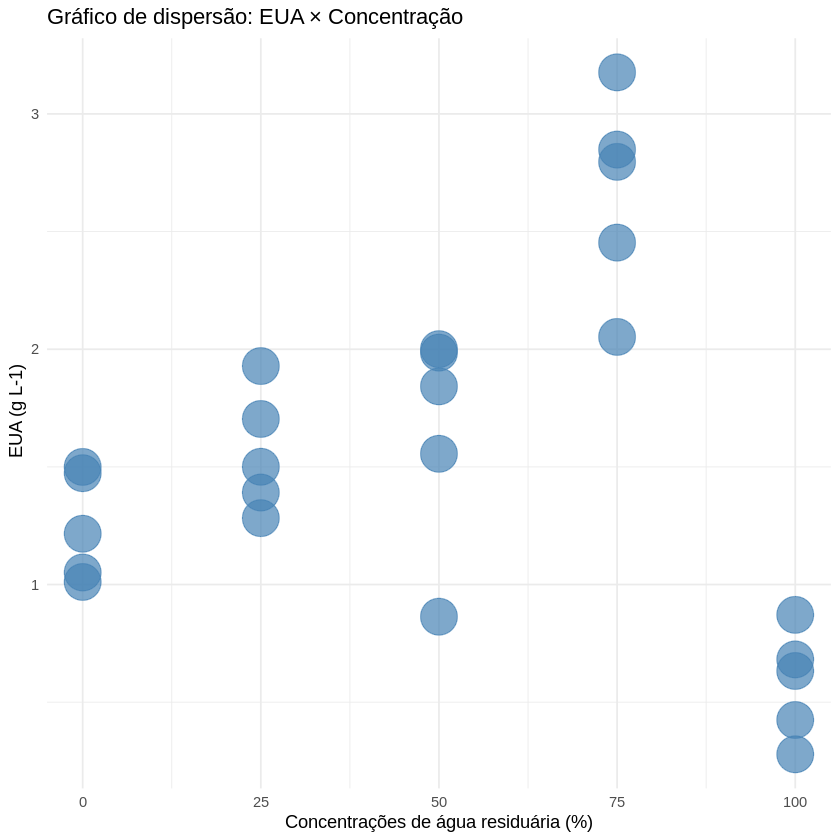

In [12]:
#plotando gráfico de dispersão dos dados

ggplot(dados, aes(x = Concentracao, y= EUA)) +
       geom_point(
         color = "steelblue",
         alpha = 0.7,
         size = 10
   ) +
       labs(
           x = "Concentrações de água residuária (%)",
           y = " EUA (g L-1)",
           title = "Gráfico de dispersão: EUA × Concentração"
       ) +
   theme_minimal()


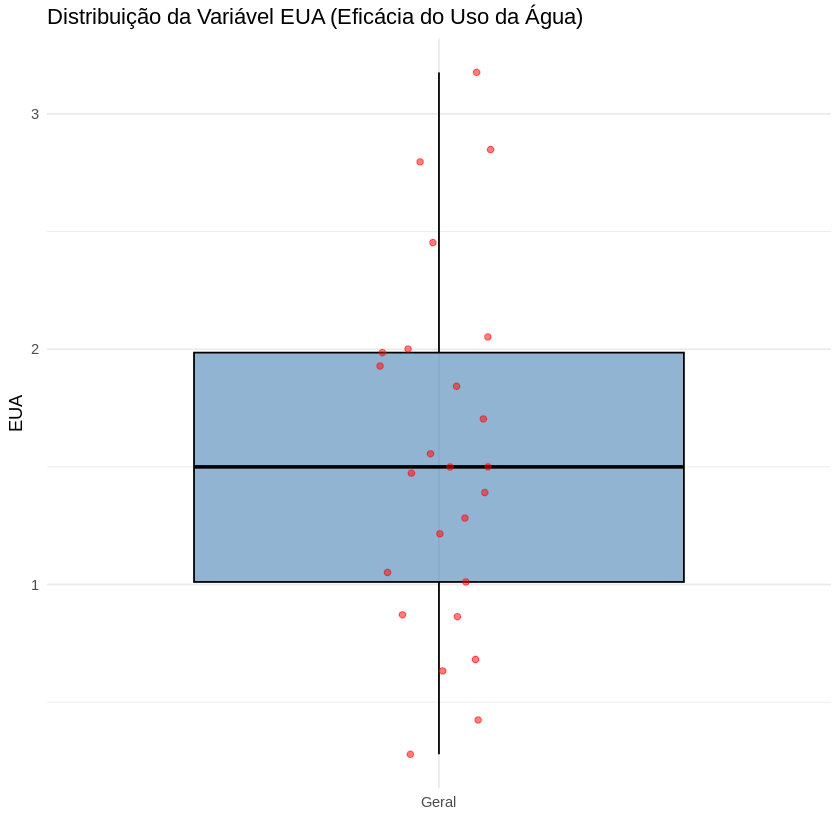

In [13]:
#Plotando gráfico de boxplot com pontos

ggplot(dados, aes(x = "Geral", y = EUA)) +
  geom_boxplot(
    fill = "steelblue",
    color = "black",
    alpha = 0.6,
    outlier.color = "red"
  ) +
  geom_jitter(color = "red", width = 0.1, alpha = 0.5) + # geom_jitter evita que pontos sobrepostos escondam dados
  labs(
    x = "",
    y = "EUA",
    title = "Distribuição da Variável EUA (Eficácia do Uso da Água)"
  ) +
  theme_minimal()

#### Modelagem dos dados com modelos empíricos

Para todos os modelos, nossa variável resposta é a EUA = eficiencia do uso da água em função da concentração de água residuária.

In [14]:
# modelagem com regressão simples -----------------------------------------

mod1 <- lm(EUA ~ Concentracao, data = dados)


#Equação do Modelo Linear (mod1)
cf1 <- coef(mod1)
eq_linear <- paste0("EUA = ", round(cf1[1], 4), " + (", round(cf1[2], 4), " * Concentracao)")

print(summary(mod1))
print(eq_linear)




Call:
lm(formula = EUA ~ Concentracao, data = dados)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.21413 -0.57801 -0.08902  0.44480  1.65993 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)   1.5889135  0.2677183   5.935 4.74e-06 ***
Concentracao -0.0009633  0.0043718  -0.220    0.828    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.7728 on 23 degrees of freedom
Multiple R-squared:  0.002107,	Adjusted R-squared:  -0.04128 
F-statistic: 0.04855 on 1 and 23 DF,  p-value: 0.8275

[1] "EUA = 1.5889 + (-0.001 * Concentracao)"


`geom_smooth()` using formula = 'y ~ x'


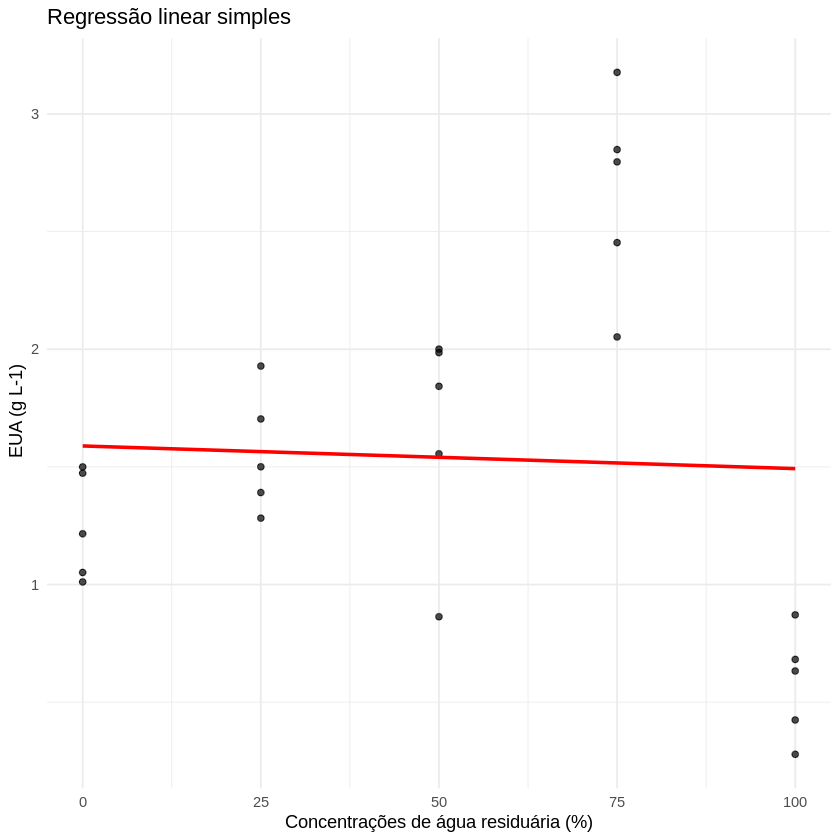

In [15]:
#plotar gráfico do modelo linear



p1<- ggplot(dados, aes(x = Concentracao, y = EUA)) +
  geom_point(alpha = 0.7) +
  geom_smooth(method = "lm", se = FALSE, color = "red") +
  labs(
    x = "Concentrações de água residuária (%)",
    y = " EUA (g L-1)",
    title = "Regressão linear simples"
  ) +
  theme_minimal()

p1

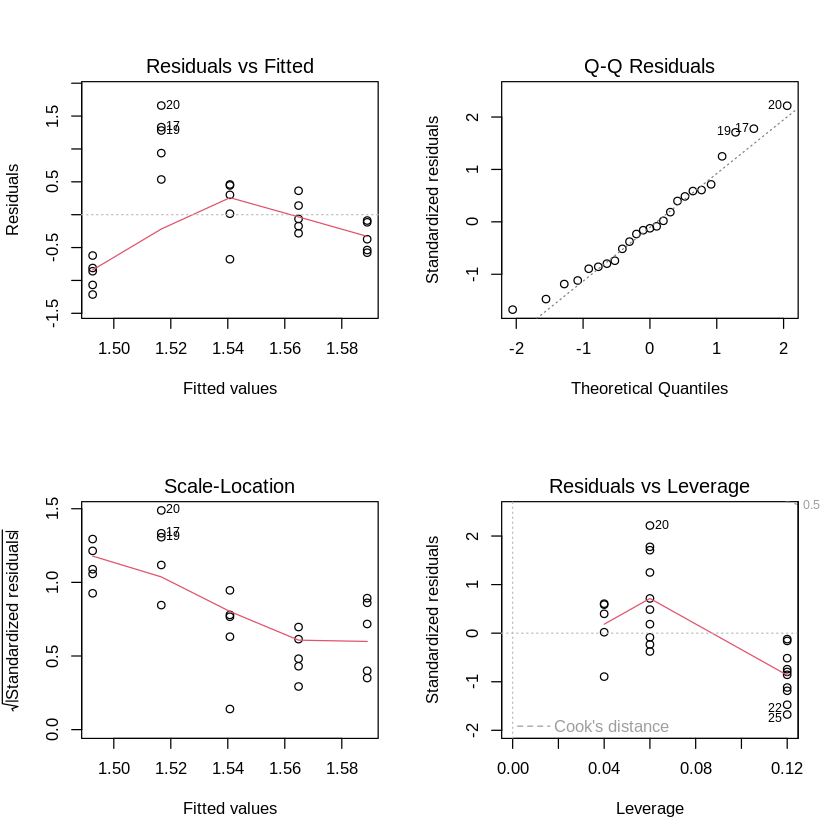

In [16]:
#plotar gráfico de diagnostico do modelo

par(mfrow = c(2,2))
plot(mod1)

In [17]:
# modelagem com modelo quadrático -----------------------------------------


mod2 <- lm(EUA ~ Concentracao + I(Concentracao^2), data = dados)

# 1. Equação do Modelo quadrático (mod2)
cf2 <- coef(mod2)
eq_quadra <- paste0("EUA = ", round(cf2[1], 4), " + (", round(cf2[2], 4), " * Concentracao)",
                    " + (", round(cf2[3], 5), " * Concentracao^2)")


print(summary(mod2))
print(eq_quadra)


Call:
lm(formula = EUA ~ Concentracao + I(Concentracao^2), data = dados)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.23024 -0.34071 -0.09323  0.25924  1.38352 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)        1.0361074  0.2599064   3.986 0.000623 ***
Concentracao       0.0432611  0.0123152   3.513 0.001963 ** 
I(Concentracao^2) -0.0004422  0.0001181  -3.745 0.001121 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.6175 on 22 degrees of freedom
Multiple R-squared:  0.3906,	Adjusted R-squared:  0.3352 
F-statistic:  7.05 on 2 and 22 DF,  p-value: 0.004306

[1] "EUA = 1.0361 + (0.0433 * Concentracao) + (-0.00044 * Concentracao^2)"


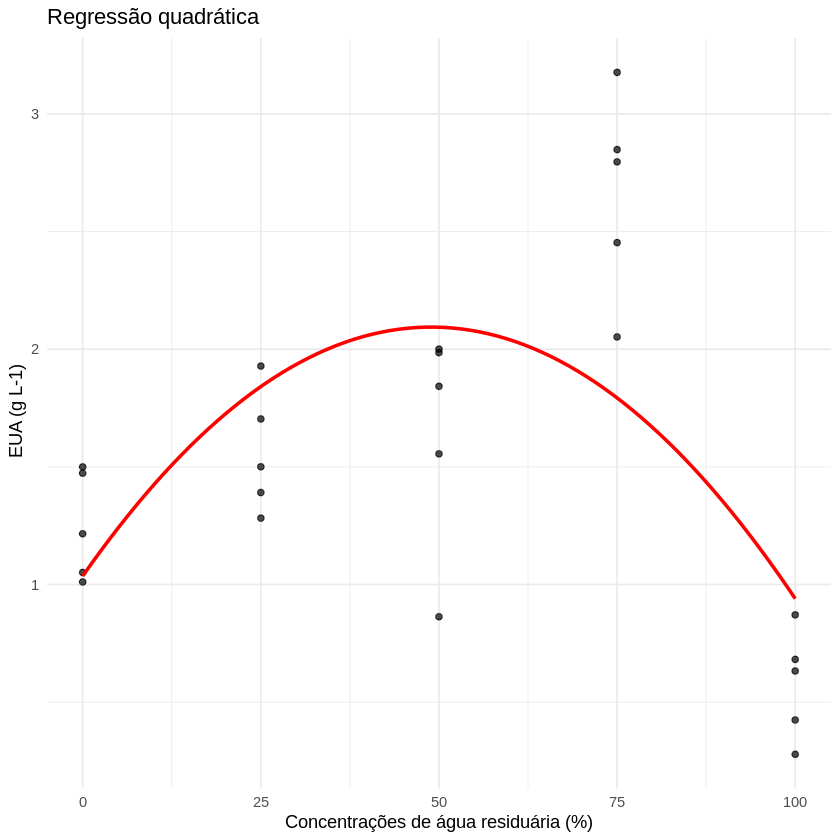

In [18]:
# plotar gráfico do modelo quadrático



p2<- ggplot(dados, aes(x = Concentracao, y = EUA)) +
  geom_point(alpha = 0.7) +
  geom_smooth(
    method = "lm",
    formula = y ~ x + I(x^2),
    se = FALSE,
    color = "red"
  ) +
  labs(
    x = "Concentrações de água residuária (%)",
    y = " EUA (g L-1)",
    title = "Regressão quadrática"
  ) +
  theme_minimal()

p2

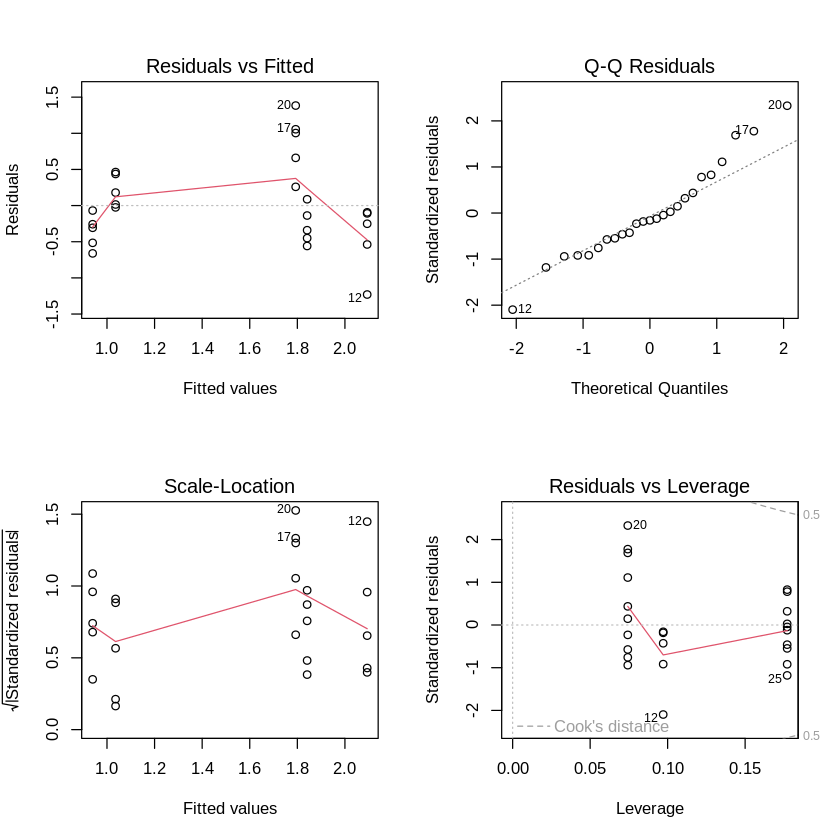

In [19]:
#plotar gráfico de diagnostico do modelo

par(mfrow = c(2,2))
plot(mod2)

In [20]:
# modelagem com modelo cúbico --------------------------------------------

mod3 <- lm(EUA ~ Concentracao + I(Concentracao^2) + I(Concentracao^3), data = dados)

# Equação do Modelo cúbico (mod3)

cf3 <- coef(mod3)

eq_cub <- paste0("EUA = ", round(cf3[1], 4), " + (", round(cf3[2], 4), " * Concentracao)",
                 " + (", round(cf3[3], 5), " * Concentracao^2)",
                 " + (", format(round(cf3[4], 8), scientific = FALSE), " * Concentracao^3)")


print(summary(mod3))
print(eq_cub)


Call:
lm(formula = EUA ~ Concentracao + I(Concentracao^2) + I(Concentracao^3), 
    data = dados)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.23024 -0.25125  0.01704  0.21945  0.80734 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)        1.324e+00  1.995e-01   6.638 1.43e-06 ***
Concentracao      -3.933e-02  2.030e-02  -1.937 0.066290 .  
I(Concentracao^2)  1.862e-03  5.156e-04   3.613 0.001634 ** 
I(Concentracao^3) -1.536e-05  3.389e-06  -4.534 0.000181 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4493 on 21 degrees of freedom
Multiple R-squared:  0.692,	Adjusted R-squared:  0.648 
F-statistic: 15.73 on 3 and 21 DF,  p-value: 1.366e-05

[1] "EUA = 1.3242 + (-0.0393 * Concentracao) + (0.00186 * Concentracao^2) + (-0.00001536 * Concentracao^3)"


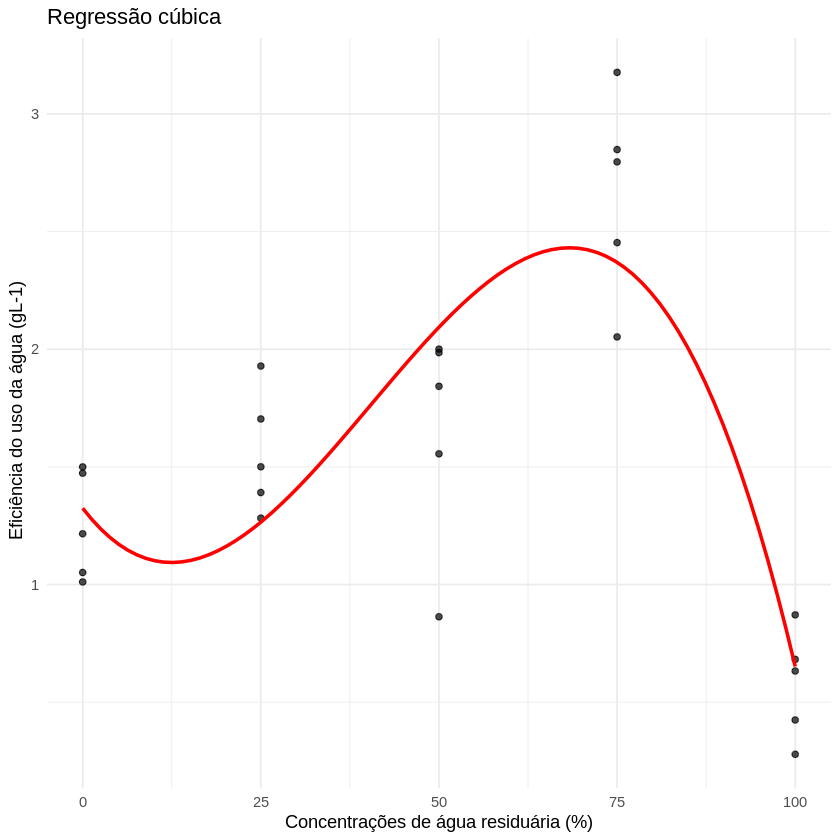

In [21]:
# plotar do gráfico do modelo cúbico


p3 <-ggplot(dados, aes(x = Concentracao, y = EUA)) +
  geom_point(alpha = 0.7) +
  geom_smooth(
    method = "lm",
    formula = y ~ x + I(x^2) + I(x^3),
    se = FALSE,
    color = "red"
  ) +
  labs(
    x = "Concentrações de água residuária (%)",
    y = " Eficiência do uso da água (gL-1)",
    title = "Regressão cúbica"
  ) +
  theme_minimal()

p3



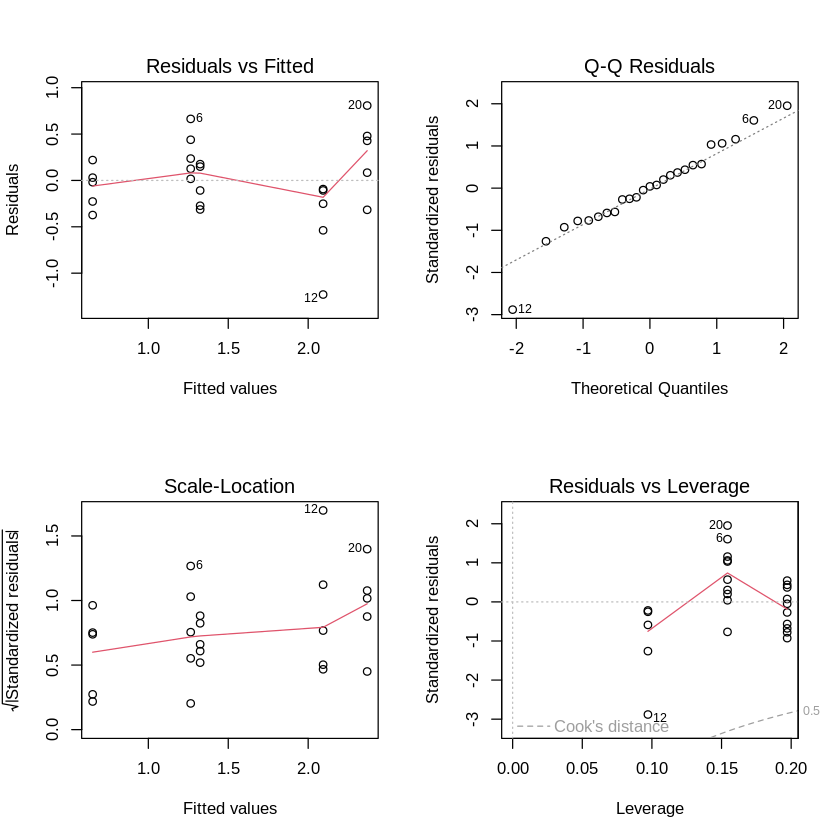

In [22]:
#plotar gráfico de diagnostico do modelo

par(mfrow = c(2,2))
plot(mod3)

`geom_smooth()` using formula = 'y ~ x'


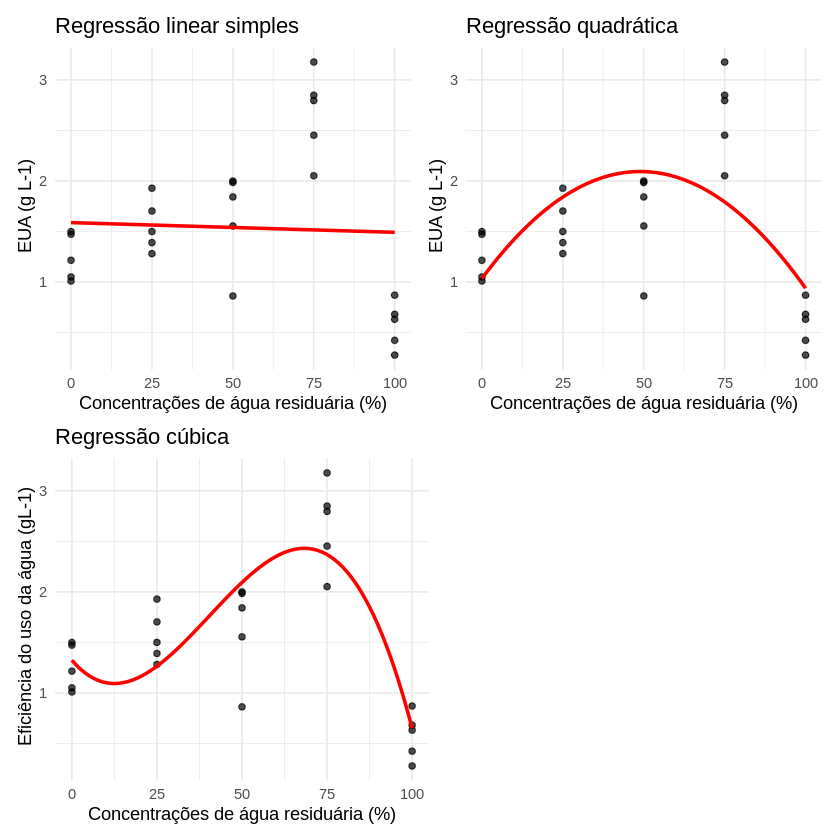

In [23]:
#criando gráfico para comparação
layout_final <- (p1 | p2 )/
                (p3| plot_spacer())


# Visualizar no RStudio
layout_final

 Após a modelagem, conseguimos ver que o modelo cúbico se mostrou melhor para explicar a variabilidade dos dados, com seu $R^2$ mais próximo a 1 do que os outros modelos. A parti disso, iremos calcular algumas métricas para entender se o modelo cúbico é mesmo o melhor para a modelagem.







#### Métricas de treino

In [24]:
# criando função para calcular as métricas de treino do modelo

met_treino <- function(modelo){

  # variável resposta usada no modelo
  y <- model.response(model.frame(modelo))

  # resíduos
  erro_treino <- residuals(modelo)

  # métricas
  treino_mad  <- mean(abs(erro_treino))             # MAD (MAE)
  treino_mbe  <- mean(erro_treino)                  # MBE
  treino_rmse <- sqrt(mean(erro_treino^2))          # RMSE

  treino_mape <- mean(abs(erro_treino / y)) * 100   # MAPE

  # NSE (equivalente ao R² para lm com intercepto)
  treino_nse <- 1 - (sum(erro_treino^2) / sum((y - mean(y))^2))

  # AIC
  aic_mod <- AIC(modelo)

  return(list(
    MAD  = treino_mad,
    MBE  = treino_mbe,
    RMSE = treino_rmse,
    MAPE = treino_mape,
    NSE  = treino_nse,
    AIC  = aic_mod
  ))
}


* MAD, nos diz em média, o quanto as previsões do seu modelo estão afastadas dos valores reais observado. quanto mais baixo o MAD, melhor o modelo para previsão do treino.

* MAPE, nos diz em média, qual é o percentual de erro das previsões do modelo em relação aos valores reais observados.

* MBE, nos diz em média, se o modelo tem viês positivo ou negativo. Costuma sempre se aproximar de 0,00.

* NSE, indica o poder preditivo do seu modelo em comparação à simples média dos dados. varia de - infinito a 1, quanto mais próximo de 1, melhor o poder preditivo .

* RMSE, Diz o quão bem o modelo se ajustou aos dados experimentais coletados. quanto mais baixo melhor. comparado ao MAD, se for maior, mostra que o modelo estar sofrendo com outlier.

* O Critério de Akaike (AIC) é uma medida usada para comparar modelos estatísticos e escolher o melhor entre eles. Quanto menor o AIC, melhor é esse modelo entre os outros.


In [25]:
# metricas da regressão linear simples

trei_mod1 <- met_treino(mod1)

print(trei_mod1)

$MAD
[1] 0.5973279

$MBE
[1] -9.671083e-18

$RMSE
[1] 0.7412784

$MAPE
[1] 63.31361

$NSE
[1] 0.002106635

$AIC
[1] 61.97798



In [26]:
# metricas da regressão quadrática

trei_mod2 <- met_treino(mod2)

print(trei_mod2)

$MAD
[1] 0.4435308

$MBE
[1] 3.586541e-17

$RMSE
[1] 0.5792905

$MAPE
[1] 40.02647

$NSE
[1] 0.3905834

$AIC
[1] 51.64937



In [27]:
# metricas da regressão cúbica

trei_mod3 <- met_treino(mod3)

print(trei_mod3)

$MAD
[1] 0.3081574

$MBE
[1] -2.775558e-18

$RMSE
[1] 0.411804

$MAPE
[1] 26.8538

$NSE
[1] 0.6920342

$AIC
[1] 36.58654



Os resultados das métricas indicaram bom
desempenho. O desvio absoluto médio (MAD =
0,3082 g L-1) e a raiz do erro quadrático médio
(RMSE = 0,4118 g L-1) demonstram que os erros de
predição são relativamente baixos. O erro percentual
absoluto médio (MAPE = 26,85%) indica erro
relativo moderado, enquanto o erro médio (MBE ≈ 0)
evidencia ausência de viés sistemático. Esses resultados indicam que o modelo
apresenta desempenho adequado, sendo capaz de
representar satisfatoriamente a relação entre a
concentração de água residuária tratada e a eficiência
do uso da água na produção de mudas de maracujá
amarelo.

#### Métricas de validação

In [28]:
# criando função para calcular as métricas de validação do modelo

met_val <- function(modelo){

 y <- model.response(model.frame(modelo))

# Cálculo LOOCV integrado
erro_loocv <- residuals(modelo) / (1 - hatvalues(modelo)) # validação cruzada

loocv_mse  <- mean(erro_loocv^2)

loocv_rmse <- sqrt(loocv_mse)

# 1. MAD (Mean Absolute Deviation) - Erro Médio Absoluto
loocv_mad <- mean(abs(erro_loocv))

# 2. MBE (Mean Bias Error) - Erro de Viés Médio
loocv_mbe <- mean(erro_loocv)

# 3. MAPE (Mean Absolute Percentage Error) - Erro Percentual Médio
loocv_mape <- mean(abs(erro_loocv / y)) * 100

# 4. NSE (Nash-Sutcliffe Efficiency) - Eficiência de Nash-Sutcliffe
# Nota: compara o modelo com a média simples dos dados
loocv_nse <- 1 - (sum(erro_loocv^2) / sum((y - mean(y))^2))

press <- sum(erro_loocv^2)
sst   <- sum((y - mean(y))^2)

loocv_r2 <- 1 - (press / sst)

  return(list(
    MAD  = loocv_mad,
    MBE  = loocv_mbe,
    RMSE = loocv_rmse,
    MAPE = loocv_mape,
    NSE  = loocv_nse,
    r2  = loocv_r2
  ))

}

In [29]:
# metricas da regressão linear

val_mod1 <- met_val(mod1)

print(val_mod1)

$MAD
[1] 0.6519589

$MBE
[1] -0.01866821

$RMSE
[1] 0.80819

$MAPE
[1] 70.61502

$NSE
[1] -0.1861739

$r2
[1] -0.1861739



In [30]:
# metricas da regressão quadrática

val_mod2 <- met_val(mod2)

print(val_mod2)

$MAD
[1] 0.4973848

$MBE
[1] -0.006427335

$RMSE
[1] 0.6421269

$MAPE
[1] 46.33451

$NSE
[1] 0.2512047

$r2
[1] 0.2512047



In [31]:
# metricas da regressão cúbica

val_mod3 <- met_val(mod3)

print(val_mod3)

$MAD
[1] 0.3624957

$MBE
[1] 0.004778668

$RMSE
[1] 0.4765494

$MAPE
[1] 31.92911

$NSE
[1] 0.5875823

$r2
[1] 0.5875823



O coeficiente de determinação reduziu para $R^2$ =
0,5876, indicando que 58,76% da variabilidade da
eficiência do uso da água em dados independentes é
explicada pelo modelo. Embora inferior ao obtido na
fase de treinamento, essa redução é esperada e reflete
uma estimativa mais realista da capacidade preditiva.
De forma semelhante, o coeficiente NSE (0,5876)
confirma que o modelo mantém desempenho
satisfatório. A redução moderada entre treino e
validação indica ausência de sobreajuste severo,
evidenciando boa capacidade de generalização,
característica fundamental em modelos preditivos.
As métricas de erro apresentaram aumento esperado
na fase de validação. O RMSE (0,4765 g L-1) e o
MAD (0,3625 g L-1) permaneceram em níveis
aceitáveis, enquanto o MAPE (31,93%) indica erro
percentual moderado. O MBE (0,0048) permaneceu
próximo de zero, confirmando ausência de viés
sistemático. o aumento moderado da diferença
entre os erros de treinamento e validação indica robustez do modelo cúbico, sem evidências de
overfitting severo.

### Análise de variância (ANOVA)

Para o modelo cúbico, iremos realizar a analise de variância a fim de entender quais variáveis exercem efeito significativo na varíavel resposta. Diante dessa situação, iremos verificar se o modelo antende o pressuposto de normalidade.

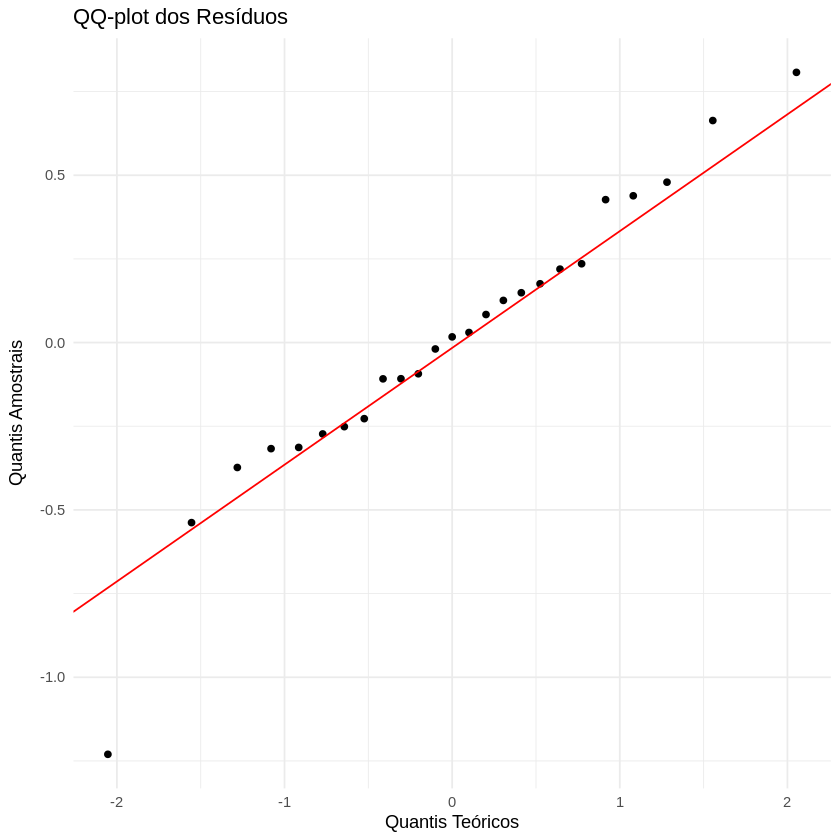

In [32]:
res <- residuals(mod3)

qq<-ggplot(data.frame(res = res), aes(sample = res)) +
         stat_qq() +
         stat_qq_line(color = "red") +
         labs(title = "QQ-plot dos Resíduos",
              x = "Quantis Teóricos",
              y = "Quantis Amostrais") +
         theme_minimal()

qq

o pressuposto de normalidade dos
resíduos foi verificado por meio do gráfico quantil
quantil (Q-Q plot), no qual se observou
boa aderência dos dados à distribuição normal,
evidenciada pela proximidade dos pontos à reta de
referência.

In [34]:
#teste ANOVA para verificação das variaveis

anova_3 <- anova(mod3)

anova_3

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Concentracao,1,0.02900066,0.02900066,0.1436502,7.084840e-01
I(Concentracao^2),1,5.34790507,5.34790507,26.4899943,4.240918e-05
I(Concentracao^3),1,4.14987463,4.14987463,20.5557417,1.813623e-04
Residuals,21,4.23956326,0.20188396,NA,NA


Os resultados dos coeficientes da regressão indicaram que o termo linear não foi estatisticamente significativo (p = 0,7085), enquanto
os termos quadrático e cúbico apresentaram alta
significância (p < 0,001). Esses resultados evidenciam que a variável resposta
apresenta comportamento não linear em relação à
concentração de água residuária, reforçando a
inadequação de modelos lineares para a descrição do
fenômeno.

### Análise do ponto ótimo

Com base no modelo cúbico ajustado, foi
determinado o ponto ótimo correspondente à máxima
eficiência do uso da água, por meio da derivação da
equação de regressão.  

(Intercept)      Concentracao I(Concentracao^2) I(Concentracao^3) 
     1.324200e+00     -3.932547e-02      1.862498e-03     -1.536495e-05

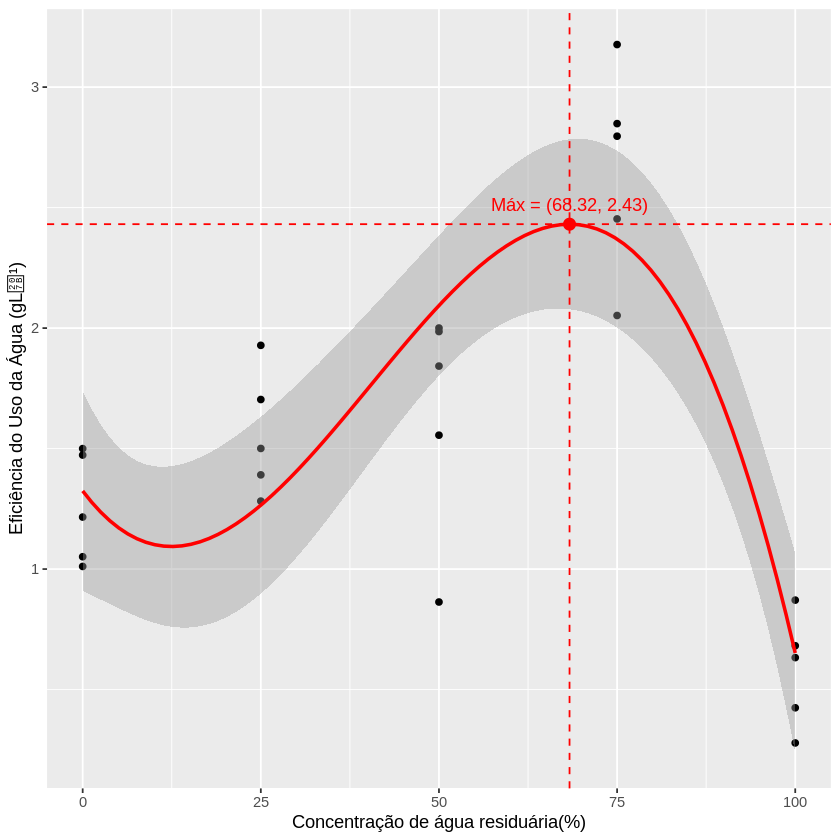

In [36]:
# ⁠concentração máxima do dados do modelo cúbico -------------------------------------------

# 1. Extrair os coeficientes do modelo cúbico (mod3)

coef_mod <- coef(mod3)
coef_mod

b <- coef_mod["Concentracao"]
c <- coef_mod["I(Concentracao^2)"]
d <- coef_mod["I(Concentracao^3)"]

# derivada: b + 2c*x + 3d*x² = 0
roots <- polyroot(c(b, 2*c, 3*d))

x_opt <- Re(roots[abs(Im(roots)) < 1e-6])

y_opt <- predict(mod3, newdata = data.frame(Concentracao = x_opt))

# pegar índice do máximo
i_max <- which.max(y_opt)

# ponto máximo
x_max <- x_opt[i_max]
y_max <- y_opt[i_max]


#exibir gráfico do ponto ótimo

ponto_max_df <- data.frame(
  Concentracao = x_max,
  EUA = y_max
)

ponto_otimo <- ggplot(dados, aes(Concentracao, EUA)) +
  geom_point() +
  geom_smooth(
    method = "lm",
    formula = y ~ x + I(x^2) + I(x^3),
    se = TRUE,
    color = "red"
  ) +
  geom_point(
    data = ponto_max_df,
    aes(Concentracao, EUA),
    color = "red",
    size = 3
  ) +
  geom_vline(xintercept = x_max, linetype = "dashed", color = "red") +
  geom_hline(yintercept = y_max, linetype = "dashed", color = "red") +
  geom_text(
    data = ponto_max_df,
    aes(
      label = paste0(
        "Máx = (",
        round(Concentracao, 2),
        ", ",
        round(EUA, 2),
        ")"
      )
    ),
    vjust = -1,
    color = "red"
  )+
  labs(
    x = "Concentração de água residuária(%)",
    y = "Eficiência do Uso da Água (gL⁻¹)"
  )

ponto_otimo

O valor máximo da eficiência (2,43 g L⁻¹) foi obtido
para uma concentração de água residuária de 68,32%.
Esse resultado indica que essa concentração pode ser
utilizada para maximizar a eficiência do uso da água
nas condições experimentais avaliadas de produção
das mudas de maracujá-amarelo.

### Conclusão da Análise

O presente estudo evidenciou que a eficiência do uso
da água em mudas de maracujazeiro-amarelo
apresenta comportamento não linear em função das
concentrações de água residuária tratada, sendo
adequadamente descrita por um modelo de regressão
polinomial de terceiro grau. O modelo ajustado
apresentou
desempenho satisfatório, conforme
indicado pelos coeficientes de ajuste e métricas de
validação,
demonstrando adequada capacidade
preditiva e robustez.
A partir do modelo, foi possível identificar um ponto
ótimo de eficiência do uso da água, no qual o valor
máximo de 2,43 g L-1 foi obtido para uma
concentração de 68,32% de água residuária tratada.
Esse resultado indica que níveis intermediários de
aplicação de efluentes favorecem a eficiência hídrica,
possivelmente em função do equilíbrio entre aporte
de nutrientes e efeitos adversos em concentrações
elevadas.